In [63]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class LandslideDataset(Dataset):
    def __init__(self, X_path, y_path):
        self.X = np.load(X_path)
        self.y = np.load(y_path)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32).permute(2,0,1)
        y = torch.tensor(self.y[idx], dtype=torch.float32).permute(2,0,1)
        return x, y

In [64]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))

        bn = self.bottleneck(self.pool3(d3))

        u3 = self.up3(bn)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.final(u1)

In [67]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = LandslideDataset("X_train.npy", "y_train.npy")
test_dataset = LandslideDataset("X_test.npy", "y_test.npy")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

# get input channels
sample_X = np.load("X_train.npy")
in_channels = sample_X.shape[3]

model = UNet(in_channels).to(device)

criterion = nn.SmoothL1Loss()   # best for regression
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [68]:
print("Train size:", len(train_loader.dataset))
print("Test size:", len(test_loader.dataset))

Train size: 68
Test size: 83


In [69]:
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        pred = model(X)

        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader):.4f}")

Epoch 1, Train Loss: 0.0372
Epoch 2, Train Loss: 0.0033
Epoch 3, Train Loss: 0.0011
Epoch 4, Train Loss: 0.0004
Epoch 5, Train Loss: 0.0003
Epoch 6, Train Loss: 0.0002
Epoch 7, Train Loss: 0.0002
Epoch 8, Train Loss: 0.0002
Epoch 9, Train Loss: 0.0002
Epoch 10, Train Loss: 0.0003
Epoch 11, Train Loss: 0.0002
Epoch 12, Train Loss: 0.0001
Epoch 13, Train Loss: 0.0001
Epoch 14, Train Loss: 0.0001
Epoch 15, Train Loss: 0.0001
Epoch 16, Train Loss: 0.0001
Epoch 17, Train Loss: 0.0001
Epoch 18, Train Loss: 0.0001
Epoch 19, Train Loss: 0.0001
Epoch 20, Train Loss: 0.0001


In [70]:
model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        break

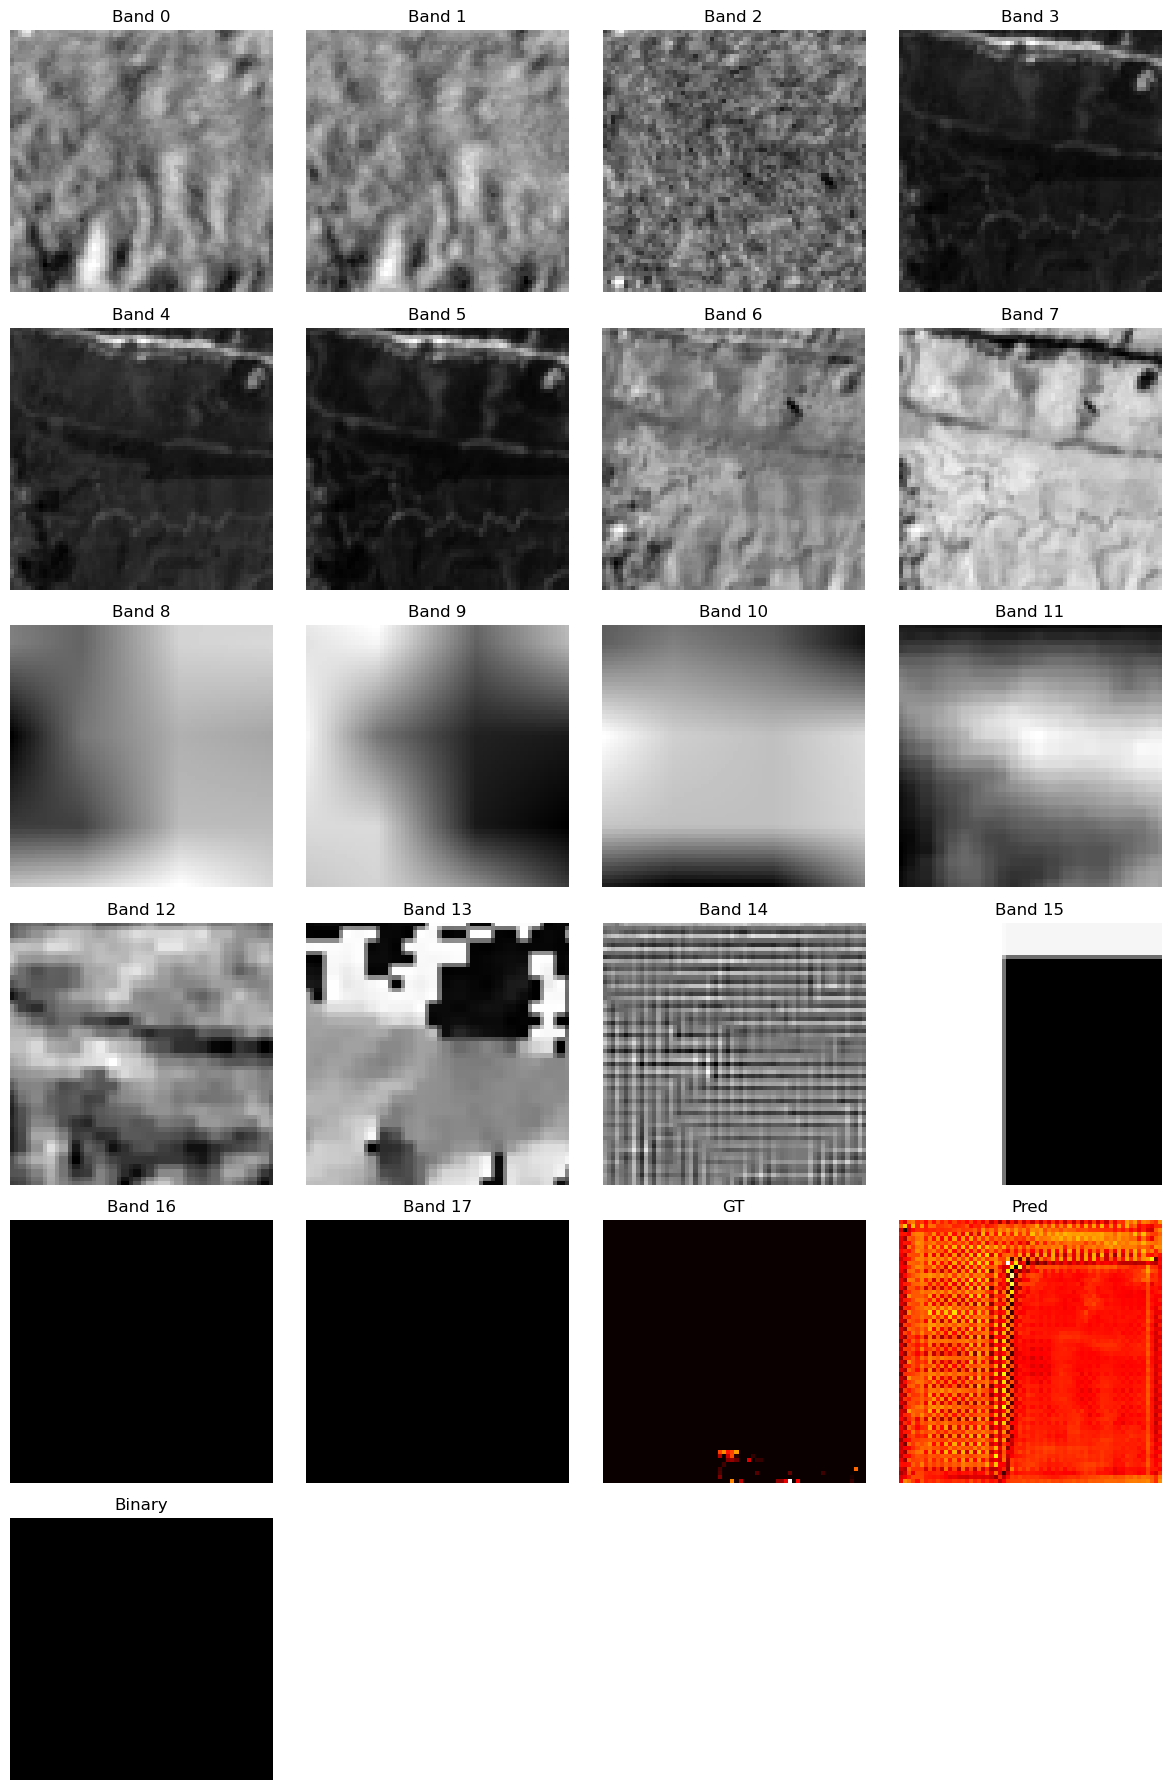

In [74]:
import matplotlib.pyplot as plt

i = 0

x = X[i].cpu()       # (C,H,W)
gt = y[i][0].cpu()   # (H,W)
pr = pred[i][0].cpu()

C = x.shape[0]

cols = 4
rows = (C + 3 + cols - 1) // cols   # +3 for GT, Pred, Binary

plt.figure(figsize=(12, 3*rows))

# ===== Plot all bands =====
for b in range(C):
    plt.subplot(rows, cols, b+1)
    plt.imshow(x[b], cmap='gray')
    plt.title(f'Band {b}')
    plt.axis('off')

# ===== GT =====
plt.subplot(rows, cols, C+1)
plt.imshow(gt, cmap='hot')
plt.title("GT")
plt.axis('off')

# ===== Prediction =====
plt.subplot(rows, cols, C+2)
plt.imshow(pr, cmap='hot')
plt.title("Pred")
plt.axis('off')

# ===== Binary =====
plt.subplot(rows, cols, C+3)
plt.imshow((pr > 0.2), cmap='gray')
plt.title("Binary")
plt.axis('off')

plt.tight_layout()
plt.show()

In [53]:
import matplotlib.pyplot as plt

def visualize_loader(loader, idx=0):
    for X, y in loader:
        X = X.cpu()
        y = y.cpu()

        # pick sample
        x = X[idx]   # (C,H,W)
        mask = y[idx][0]  # (H,W)

        C = x.shape[0]

        cols = 4
        rows = (C + 1 + cols - 1) // cols

        plt.figure(figsize=(12, 3*rows))

        # plot bands
        for b in range(C):
            plt.subplot(rows, cols, b+1)
            plt.imshow(x[b], cmap='gray')
            plt.title(f'Band {b}')
            plt.axis('off')

        # plot mask
        plt.subplot(rows, cols, C+1)
        plt.imshow(mask, cmap='hot')
        plt.title("Mask")
        plt.axis('off')

        plt.show()
        break

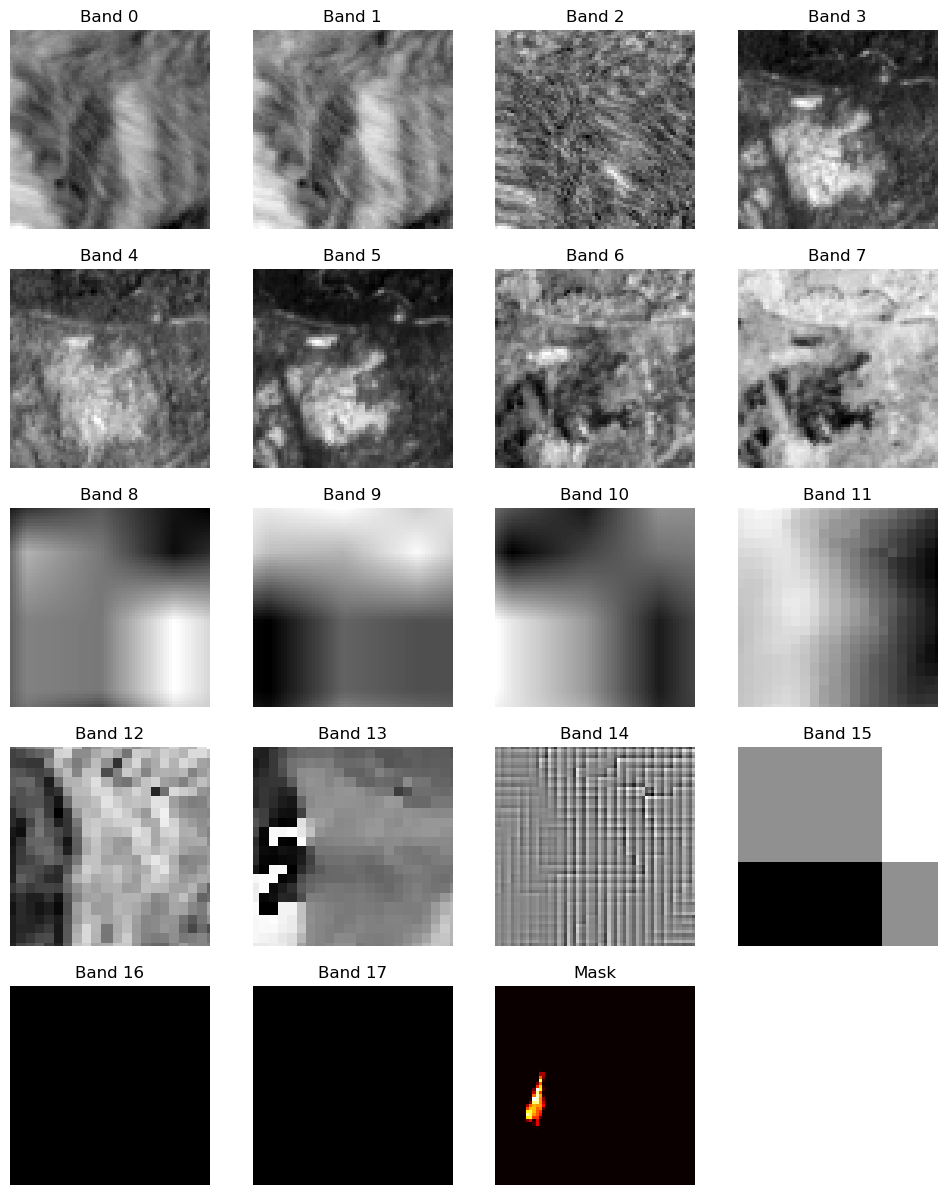

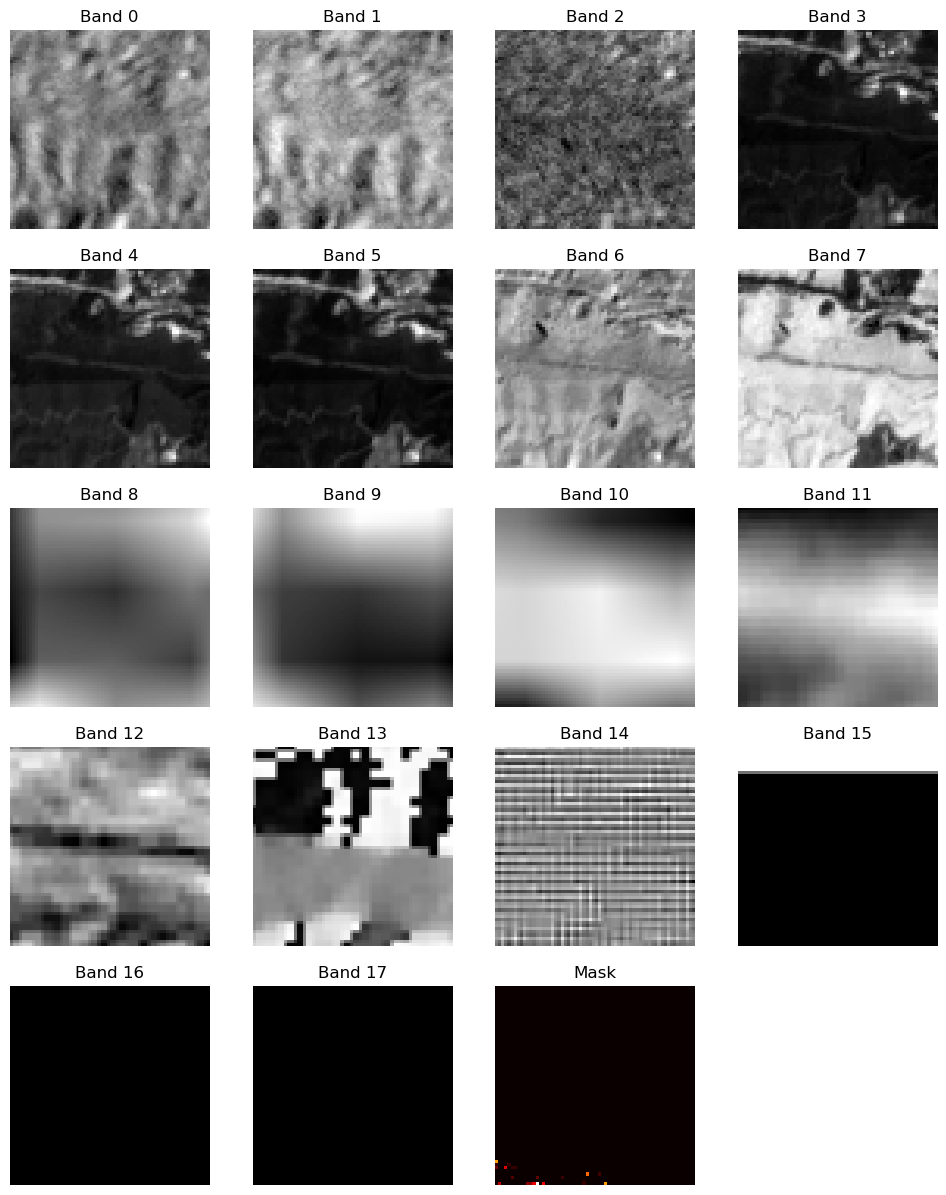

In [72]:
i=1
visualize_loader(train_loader, idx=i)
visualize_loader(test_loader, idx=i)